In [1]:
from google.colab import files
files.upload()

Saving Churn.csv to Churn.csv


{'Churn.csv': b'customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn\n7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No\n5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No\n3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes\n7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No\n9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes\n9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes\n1452-KIOVK,Male,0,No,Yes,

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

In [3]:
import pandas as pd
df = pd.read_csv("Churn.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df = df.drop(columns=["customerID"])

In [10]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


 **printing the unquie values**






In [11]:
for col in df.columns:
  print(f'{col}:{df[col].unique()}')
  print("-"*10)

gender:['Female' 'Male']
----------
SeniorCitizen:[0 1]
----------
Partner:['Yes' 'No']
----------
Dependents:['No' 'Yes']
----------
tenure:[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
----------
PhoneService:['No' 'Yes']
----------
MultipleLines:['No phone service' 'No' 'Yes']
----------
InternetService:['DSL' 'Fiber optic' 'No']
----------
OnlineSecurity:['No' 'Yes' 'No internet service']
----------
OnlineBackup:['Yes' 'No' 'No internet service']
----------
DeviceProtection:['No' 'Yes' 'No internet service']
----------
TechSupport:['No' 'Yes' 'No internet service']
----------
StreamingTV:['No' 'Yes' 'No internet service']
----------
StreamingMovies:['No' 'Yes' 'No internet service']
----------
Contract:['Month-to-month' 'One year' 'Two year']
----------
PaperlessBilling:['Yes' 'No']
----------
PaymentMethod

**checking the null values**

In [12]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
df[df['TotalCharges']==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
len(df[df['TotalCharges']==" "])

11

**convert the total charges to float**

In [15]:
df['TotalCharges'] = df ['TotalCharges'].replace({" ":"0.0"})


In [16]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


**checking the class distribution of chur**n

In [18]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**distribution of numeric features by graphs**

In [20]:
def plot_histogram(df,ColumnName):
  plt.figure(figsize=(10,5))
  sns.histplot(df[ColumnName], kde=True)
  plt.title(f'Distribution of {ColumnName}')
  col_mean = df[ColumnName].mean()
  col_median = df[ColumnName].median()
  col_std = df[ColumnName].std()
  plt.axvline(col_mean, color='red', linestyle='dashed', linewidth=1 , label ="mean")
  plt.axvline(col_median, color='green', linestyle='dashed', linewidth=1, label ="median")
  plt.legend()
  plt.show()


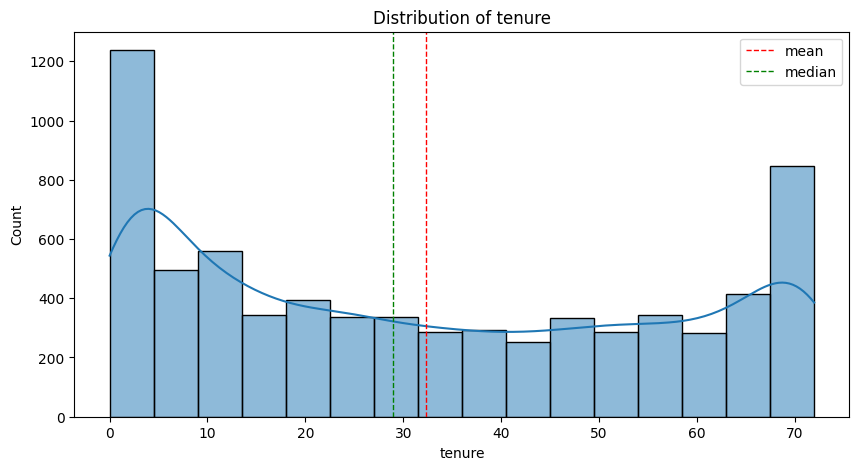

In [21]:
ColumnName = 'tenure'
plt.figure(figsize=(10,5))
sns.histplot(df[ColumnName], kde=True) # Changed from plt.histplot to sns.histplot
plt.title(f'Distribution of {ColumnName}')
col_mean = df[ColumnName].mean()
col_median = df[ColumnName].median()
col_std = df[ColumnName].std()
plt.axvline(col_mean, color='red', linestyle='dashed', linewidth=1 , label ="mean")
plt.axvline(col_median, color='green', linestyle='dashed', linewidth=1, label ="median")
plt.legend()
plt.show()

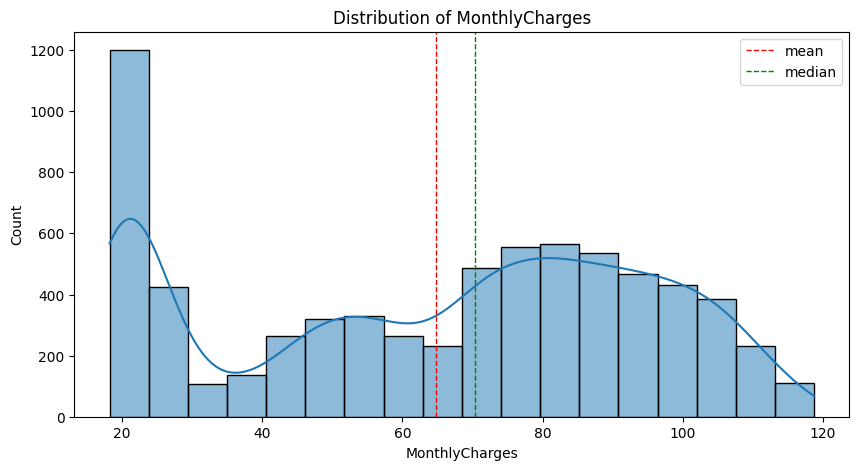

In [22]:
plot_histogram(df,'MonthlyCharges')

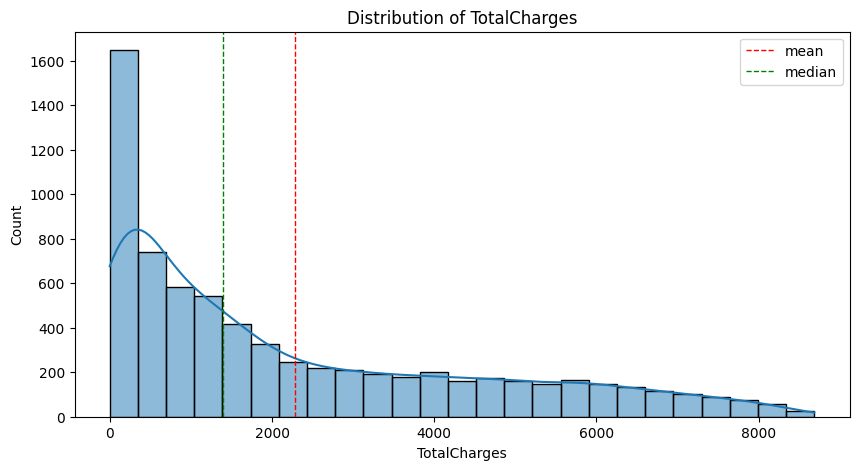

In [23]:
plot_histogram(df,'TotalCharges')

In [24]:
def plot_boxplot(df,ColumnName):
  plt.figure(figsize=(10,5))
  sns.boxplot(df[ColumnName])
  plt.title(f'Distribution of {ColumnName}')
  plt.show()

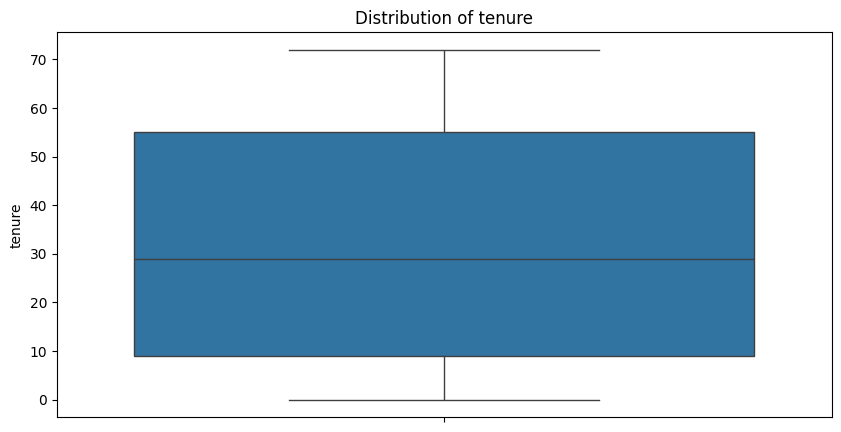

In [25]:
plot_boxplot(df,'tenure')

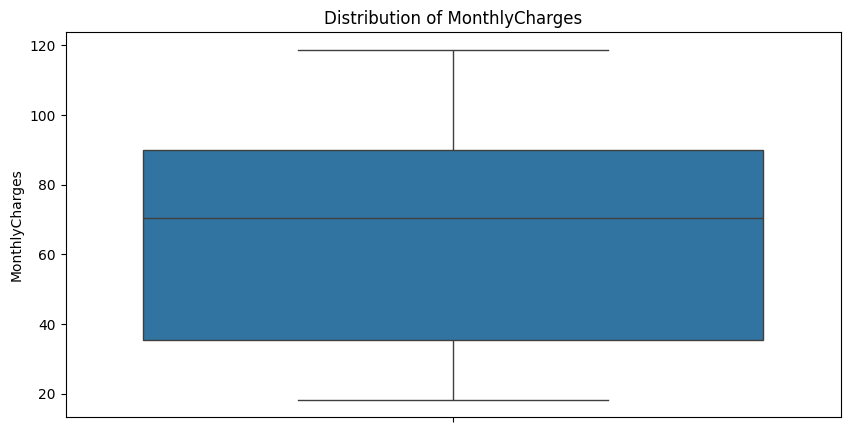

In [26]:
plot_boxplot(df,'MonthlyCharges')

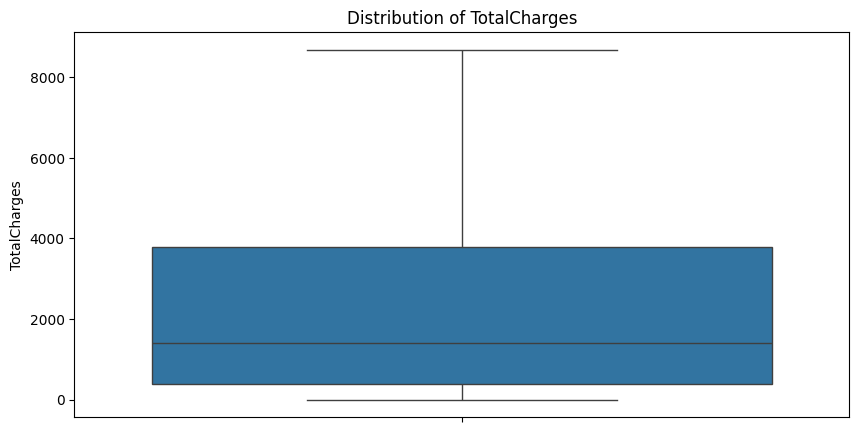

In [27]:
plot_boxplot(df,'TotalCharges')

In [28]:
print(locals().keys())


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'files', '_1', '_i2', 'np', 'pd', 'plt', 'sns', 'LabelEncoder', 'SMOTE', 'train_test_split', 'cross_val_score', 'DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier', 'accuracy_score', 'confusion_matrix', 'classification_report', 'pickle', '_i3', 'df', '_i4', '_4', '_i5', '_5', '_i6', '_i7', '_7', '_i8', '_i9', '_i10', '_10', '_i11', 'col', '_i12', '_i13', '_13', '_i14', '_14', '_i15', '_i16', '_i17', '_i18', '_i19', '_19', '_i20', 'plot_histogram', '_i21', 'ColumnName', 'col_mean', 'col_median', 'col_std', '_i22', '_i23', '_i24', 'plot_boxplot', '_i25', '_i26', '_i27', '_i28'])


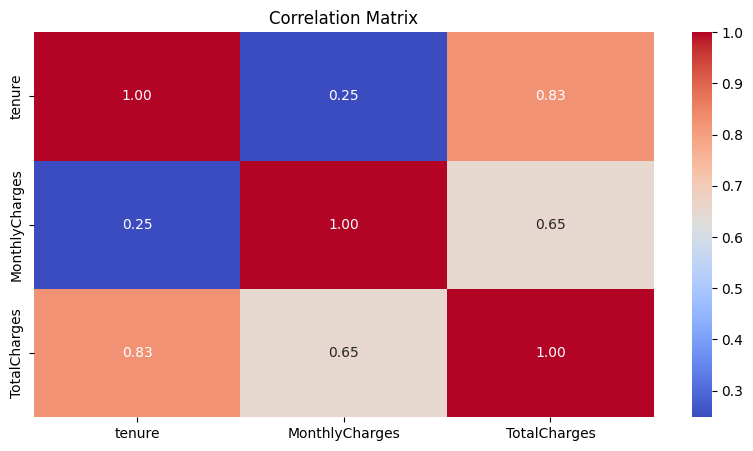

In [29]:
plt.figure(figsize=(10,5))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt= ".2f")
plt.title("Correlation Matrix")
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


**add  SeniorCitizen  into object type and count plot of object**

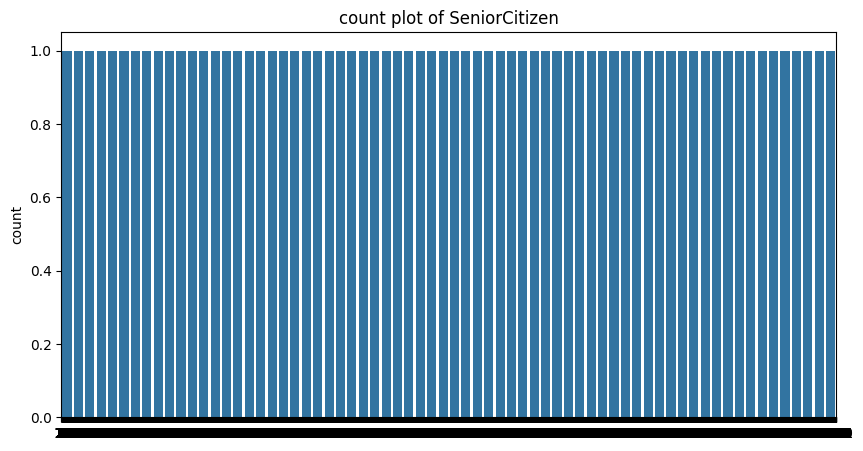

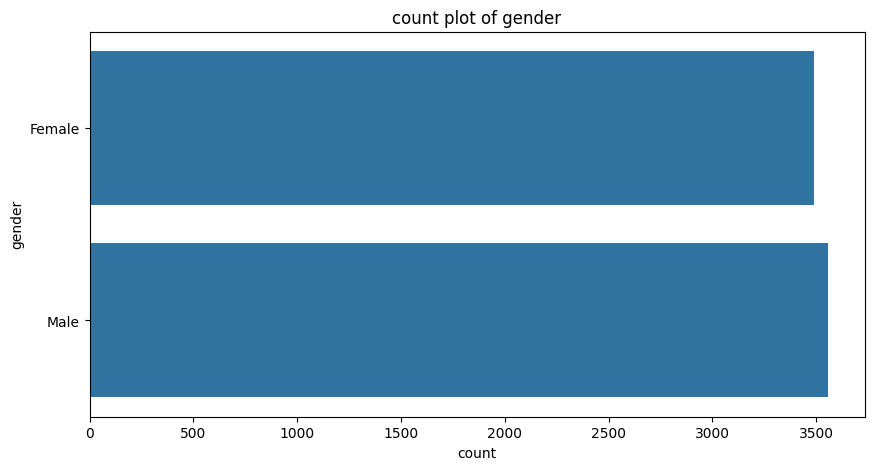

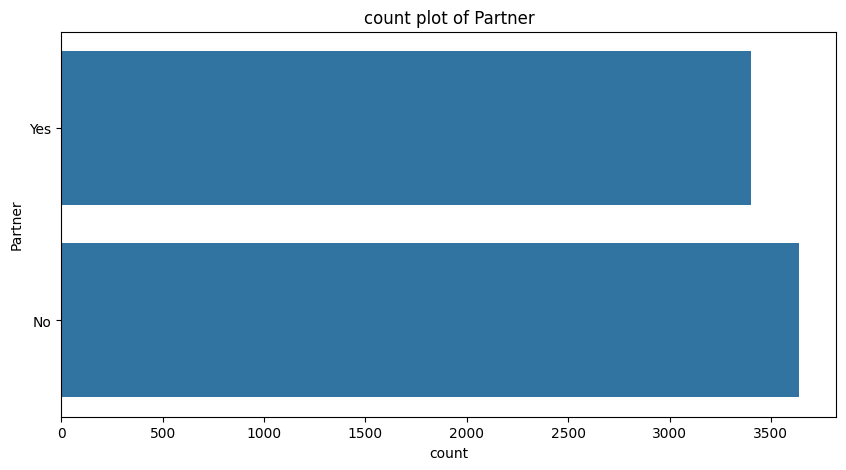

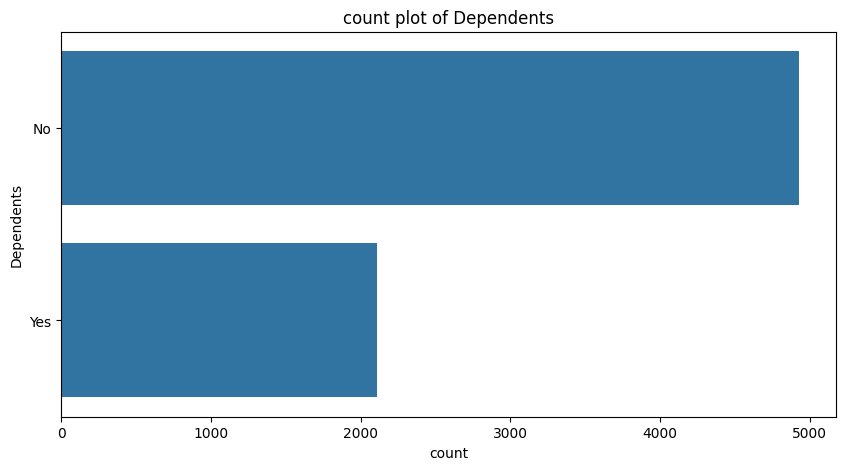

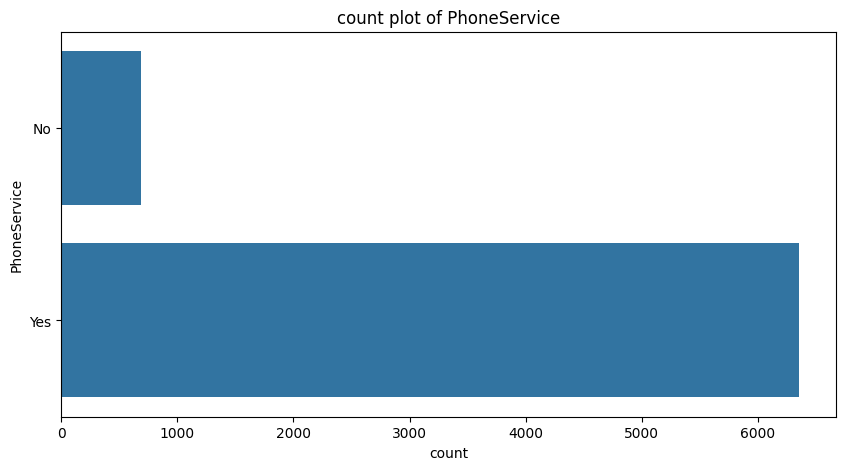

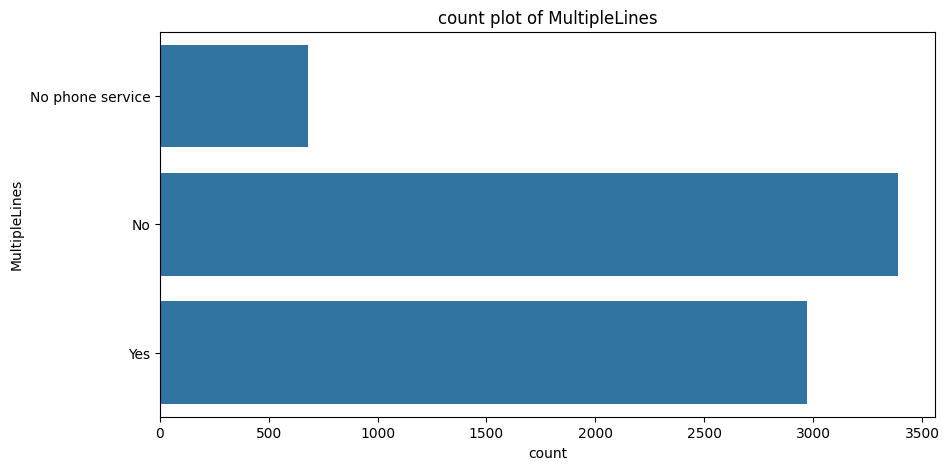

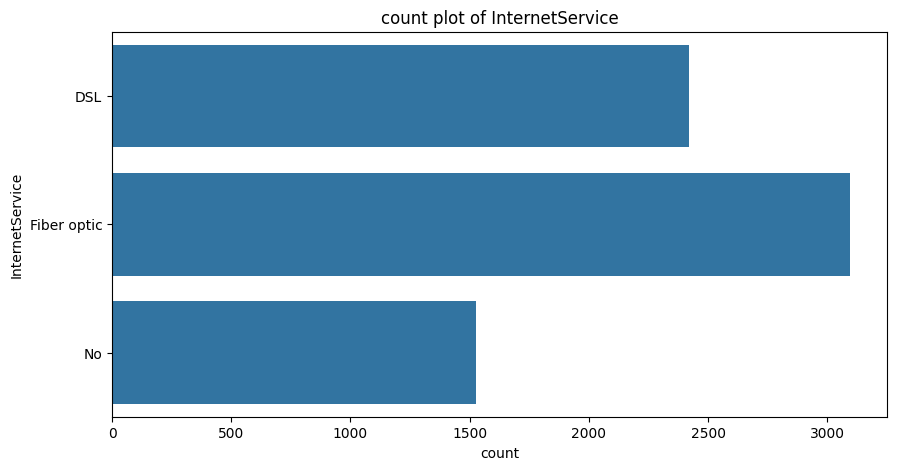

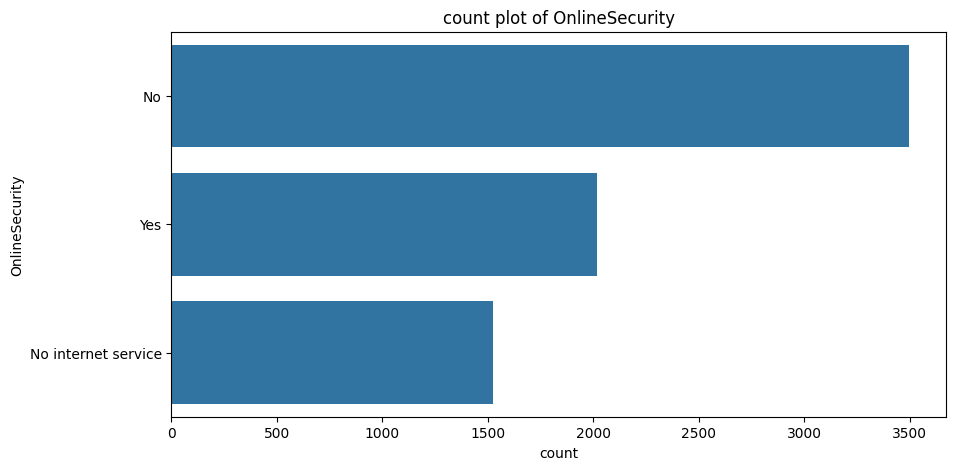

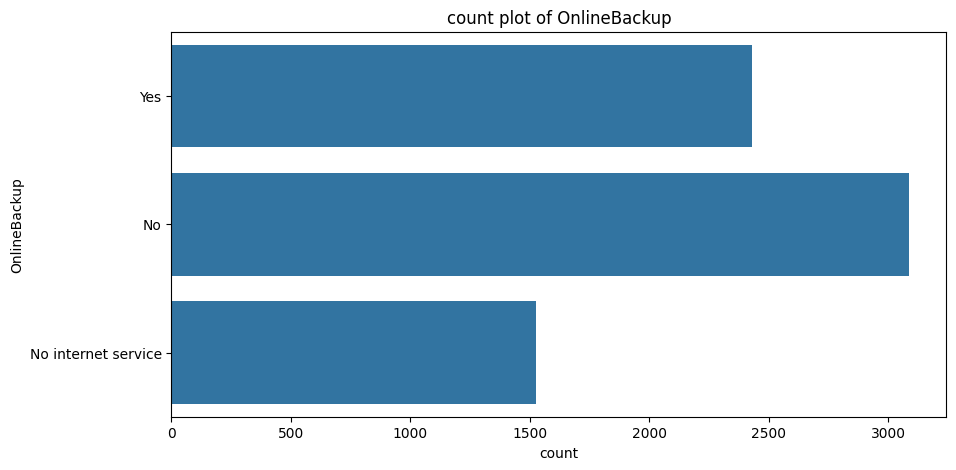

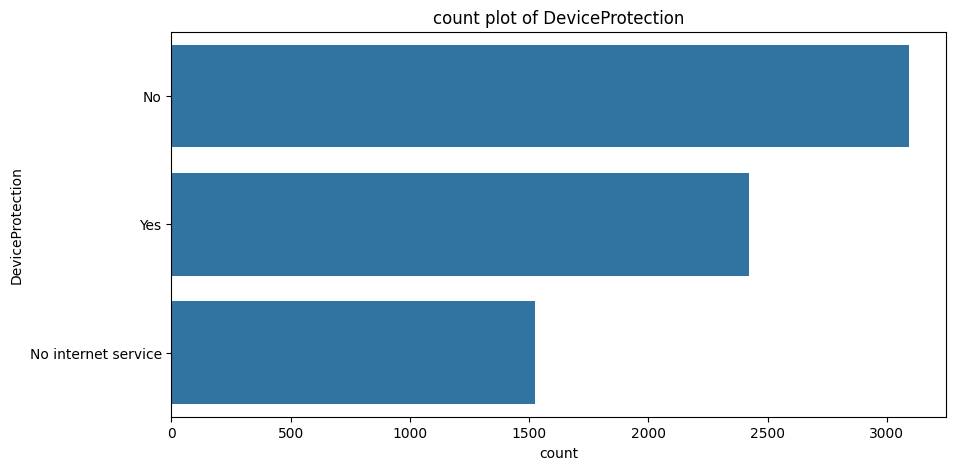

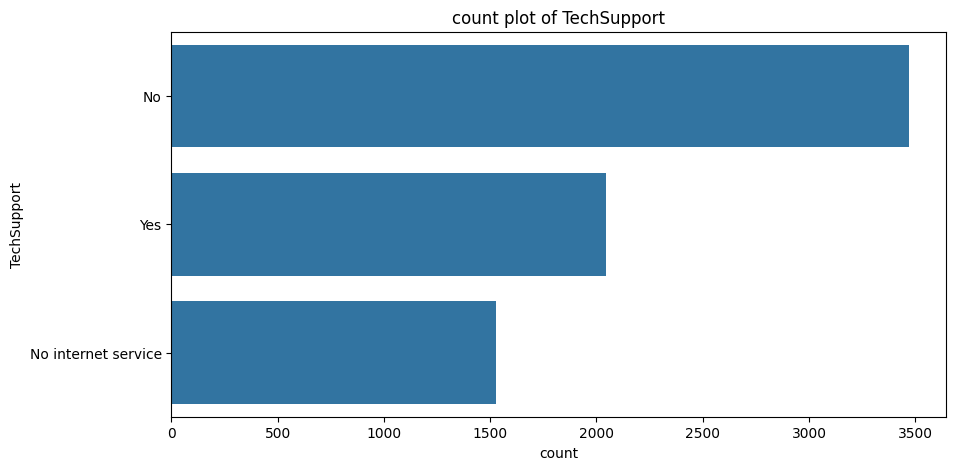

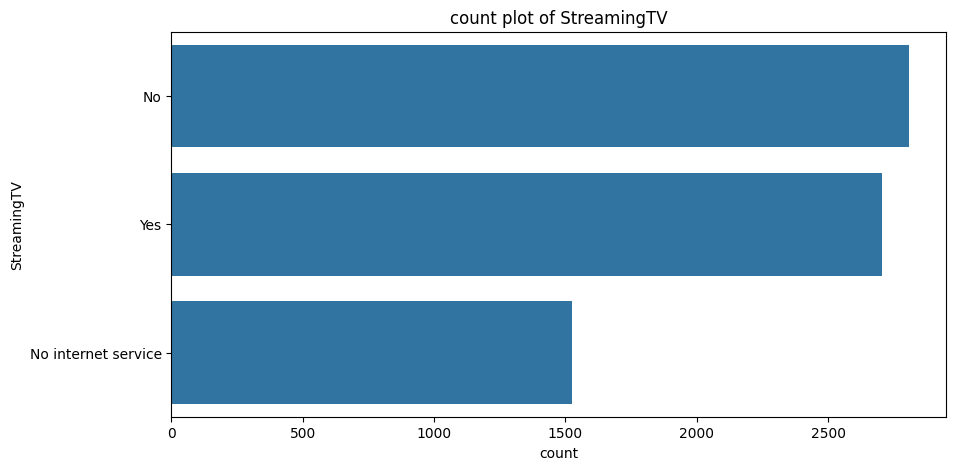

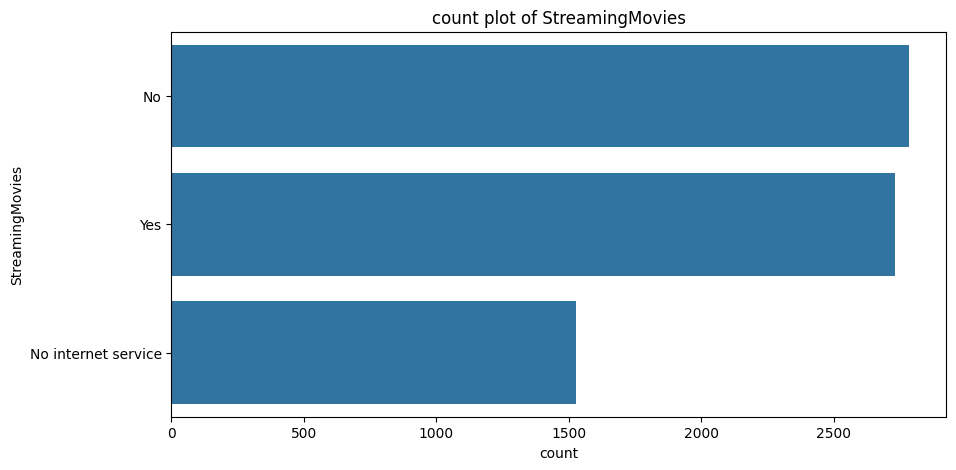

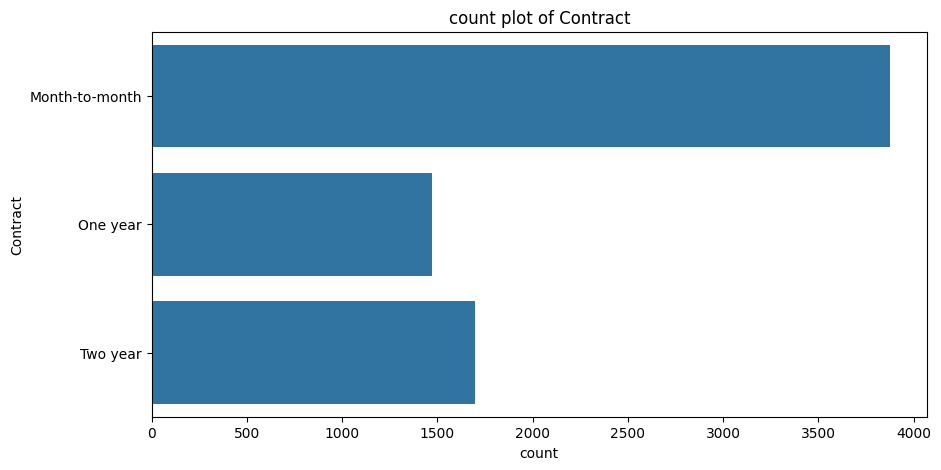

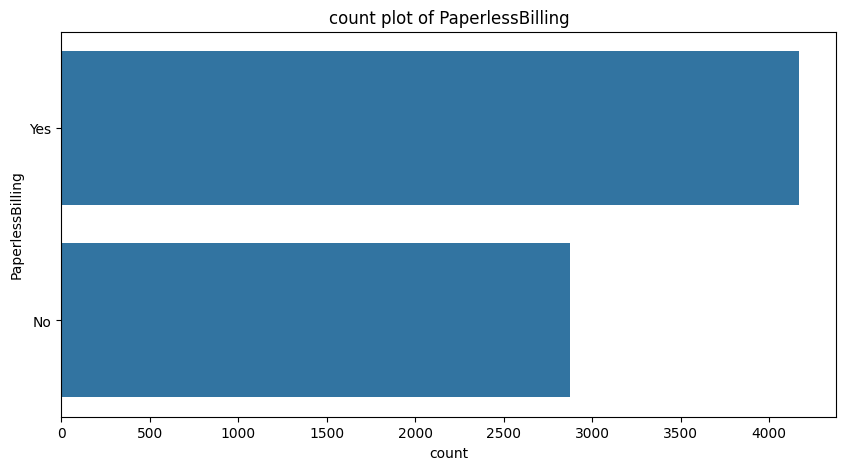

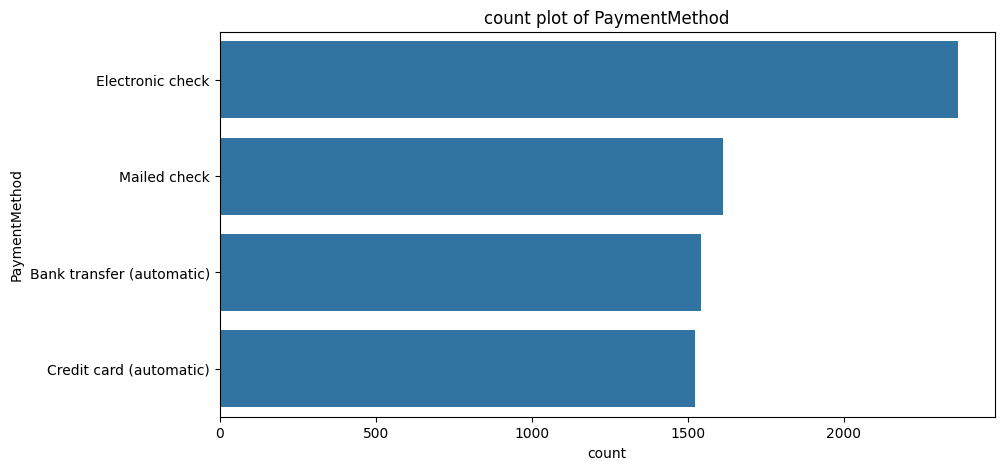

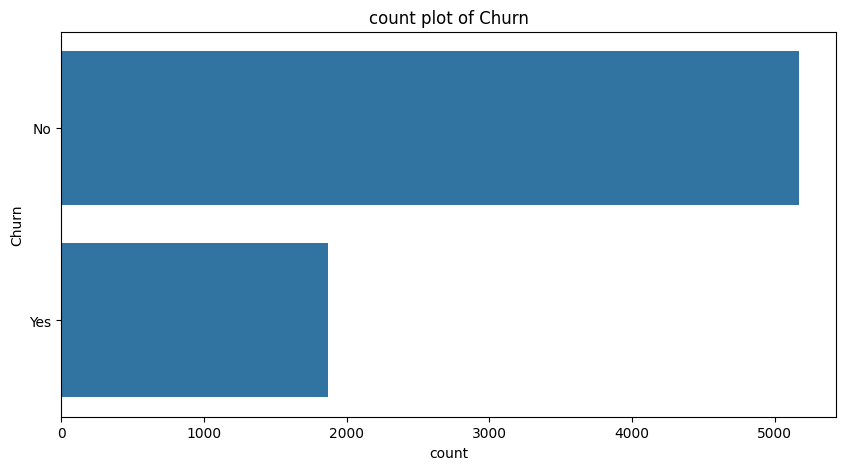

In [32]:
object_cols = df.select_dtypes(include=['object']).columns.to_list()
object_cols =["SeniorCitizen"] + object_cols


for cols in object_cols:
  plt.figure(figsize=(10,5))
  sns.countplot(df[cols])
  plt.title(f"count plot of {cols}")
  plt.show()

**make the churn into numeric**

In [33]:
df["Churn"] = df["Churn"].replace({"Yes":1,"No":0})

/tmp/ipython-input-3368294369.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes":1,"No":0})


In [34]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [35]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**label encoder for categorical features**

In [36]:
object_columns = df.select_dtypes(include=['object']).columns


In [37]:
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [40]:
encoders = {}
for columns in object_columns:
  label_encoder = LabelEncoder()
  df[columns] = label_encoder.fit_transform(df[columns])
  encoders[columns] = label_encoder

with open ("encoder.pkl","wb") as f:
  pickle.dump(encoders, f)

In [43]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [44]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


**training and test the data**

In [57]:
X = df.drop(columns=["Churn"])
Y= df["Churn"]

In [46]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [49]:
print(Y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [62]:
print (Y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


**SMOTE**

In [63]:
smote = SMOTE(random_state=42)

In [67]:
X_train_smote, Y_train_smote = smote.fit_resample(X_train,Y_train)

In [68]:
print(Y_train_smote.shape)

(8276,)


In [69]:
print(Y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)


In [71]:
print(Y_train_resampled.value_counts())


Churn
0    4138
1    4138
Name: count, dtype: int64


**Model training**

In [72]:
model ={
    "decision_tree":DecisionTreeClassifier(random_state=42),
    "random_forest":RandomForestClassifier(random_state=42),
    "xgboost":XGBClassifier(random_state=42)
}


In [76]:
model ={
    "decision_tree":DecisionTreeClassifier(random_state=42),
    "random_forest":RandomForestClassifier(random_state=42),
    "xgboost":XGBClassifier(random_state=42)
}
cv_scores ={}
for model_name,clf in model.items():
  print(f"Training {model_name} with default parameter")
  scores = cross_val_score(clf,X_train_smote,Y_train_smote,cv=5,scoring="accuracy")
  cv_scores[model_name] = scores
  print (f"{model_name} accuracy:{scores.mean():.2f}")
  print("_"*50)

Training decision_tree with default parameter
decision_tree accuracy:0.78
__________________________________________________
Training random_forest with default parameter
random_forest accuracy:0.84
__________________________________________________
Training xgboost with default parameter
xgboost accuracy:0.83
__________________________________________________


**random forest gives more accuracy compared to other parameters**

In [77]:
rfclassifier = RandomForestClassifier(random_state=42)

**model evaluation**

In [79]:
# Select the best performing model (Random Forest based on previous cross-validation)
rf_classifier = model["random_forest"]

# Train the chosen model on the resampled training data
rf_classifier.fit(X_train_smote, Y_train_smote)

# Make predictions on the test set using the trained model
Y_test_pred = rf_classifier.predict(X_test)

print("Accuracy score:\n",accuracy_score(Y_test,Y_test_pred))
print("Confusion matrix:\n",confusion_matrix(Y_test,Y_test_pred))
print("Classification report:\n",classification_report(Y_test,Y_test_pred))

Accuracy score:
 0.7785663591199432
Confusion matrix:
 [[878 158]
 [154 219]]
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [80]:
with open("model.pkl","wb") as f:
  pickle.dump(rf_classifier,f)

In [82]:
# The original error is NameError: name 'scaler' is not defined because 'scaler' was never defined or fitted.
# Also, no scaling was applied to X_train_smote before training the model, so 'scaler.transform' is not needed here.
# The `new_customer` array must also have the same number of features (19) and preprocessing as the training data.

# Example of a new customer input using a row from X_test to demonstrate the correct format
# In a real scenario, you would collect 19 features for a new customer and apply the same LabelEncoders used during training.
new_customer_example = X_test.iloc[[0]] # Taking the first row from X_test as an example for prediction input

prediction = rf_classifier.predict(new_customer_example) # Use rf_classifier (trained Random Forest model)

print("Churn" if prediction[0] == 1 else "No Churn")

Churn
